<a href="https://www.kaggle.com/code/lalit7881/vehicle-registration-analysis-2026-eda-100?scriptVersionId=318309892" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/lalit7881/transport-vehicle-registrations-january-2026/transport-january-2026-csv.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/lalit7881/transport-vehicle-registrations-january-2026/transport-january-2026-csv.csv")

In [3]:
df.head()

,Series_reference,Period,Data_value,Suppressed,STATUS,UNITS,Magnitude,Subject,Group,Series_title_1,Series_title_2,Series_title_3,Series_title_4,Series_title_5
0,TPTA.S22IA,1970.12,2771.0,NaN,F,NUMBER,0,Transport - TPT,New and Ex-Oseas Motor Vehicles Registered by ...,New Cars&Station Wagons up to 850 cc,NaN,NaN,NaN,NaN
1,TPTA.S22IA,1971.12,2076.0,NaN,F,NUMBER,0,Transport - TPT,New and Ex-Oseas Motor Vehicles Registered by ...,New Cars&Station Wagons up to 850 cc,NaN,NaN,NaN,NaN
2,TPTA.S22IA,1972.12,2037.0,NaN,F,NUMBER,0,Transport - TPT,New and Ex-Oseas Motor Vehicles Registered by ...,New Cars&Station Wagons up to 850 cc,NaN,NaN,NaN,NaN
3,TPTA.S22IA,1973.12,2101.0,NaN,F,NUMBER,0,Transport - TPT,New and Ex-Oseas Motor Vehicles Registered by ...,New Cars&Station Wagons up to 850 cc,NaN,NaN,NaN,NaN
4,TPTA.S22IA,1974.12,1282.0,NaN,F,NUMBER,0,Transport - TPT,New and Ex-Oseas Motor Vehicles Registered by ...,New Cars&Station Wagons up to 850 cc,NaN,NaN,NaN,NaN


In [4]:
df.tail()

,Series_reference,Period,Data_value,Suppressed,STATUS,UNITS,Magnitude,Subject,Group,Series_title_1,Series_title_2,Series_title_3,Series_title_4,Series_title_5
45537,TPTQ.S56ZZ,2024.12,4660781.0,NaN,F,Number,0,Transport - TPT,Motor Vehicles Currently Licensed by Type,Total All Vehicles,Total both periods,NaN,NaN,NaN
45538,TPTQ.S56ZZ,2025.03,4659464.0,NaN,F,Number,0,Transport - TPT,Motor Vehicles Currently Licensed by Type,Total All Vehicles,Total both periods,NaN,NaN,NaN
45539,TPTQ.S56ZZ,2025.06,4606776.0,NaN,F,Number,0,Transport - TPT,Motor Vehicles Currently Licensed by Type,Total All Vehicles,Total both periods,NaN,NaN,NaN
45540,TPTQ.S56ZZ,2025.09,4612946.0,NaN,F,Number,0,Transport - TPT,Motor Vehicles Currently Licensed by Type,Total All Vehicles,Total both periods,NaN,NaN,NaN
45541,TPTQ.S56ZZ,2025.12,4678980.0,NaN,F,Number,0,Transport - TPT,Motor Vehicles Currently Licensed by Type,Total All Vehicles,Total both periods,NaN,NaN,NaN


In [5]:
df.info(
)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45542 entries, 0 to 45541
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Series_reference  45542 non-null  object 
 1   Period            45542 non-null  float64
 2   Data_value        45501 non-null  float64
 3   Suppressed        0 non-null      float64
 4   STATUS            45542 non-null  object 
 5   UNITS             45542 non-null  object 
 6   Magnitude         45542 non-null  int64  
 7   Subject           45542 non-null  object 
 8   Group             45542 non-null  object 
 9   Series_title_1    45542 non-null  object 
 10  Series_title_2    22458 non-null  object 
 11  Series_title_3    0 non-null      float64
 12  Series_title_4    0 non-null      float64
 13  Series_title_5    0 non-null      float64
dtypes: float64(6), int64(1), object(7)
memory usage: 4.9+ MB


In [6]:
df.describe()

,Period,Data_value,Suppressed,Magnitude,Series_title_3,Series_title_4,Series_title_5
count,45542.000000,4.550100e+04,0.0,45542.0,0.0,0.0,0.0
mean,2003.483932,1.857272e+05,NaN,0.0,NaN,NaN,NaN
std,13.743173,5.959473e+05,NaN,0.0,NaN,NaN,NaN
min,1961.010000,0.000000e+00,NaN,0.0,NaN,NaN,NaN
25%,1994.010000,2.770000e+02,NaN,0.0,NaN,NaN,NaN
50%,2004.100000,4.492000e+03,NaN,0.0,NaN,NaN,NaN
75%,2015.060000,2.340300e+04,NaN,0.0,NaN,NaN,NaN
max,2026.010000,4.678980e+06,NaN,0.0,NaN,NaN,NaN


In [7]:
df.columns

Index(['Series_reference', 'Period', 'Data_value', 'Suppressed', 'STATUS',
       'UNITS', 'Magnitude', 'Subject', 'Group', 'Series_title_1',
       'Series_title_2', 'Series_title_3', 'Series_title_4', 'Series_title_5'],
      dtype='object')

In [8]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Series_reference        0
Period                  0
Data_value             41
Suppressed          45542
STATUS                  0
UNITS                   0
Magnitude               0
Subject                 0
Group                   0
Series_title_1          0
Series_title_2      23084
Series_title_3      45542
Series_title_4      45542
Series_title_5      45542
dtype: int64


In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.dtypes

Series_reference     object
Period              float64
Data_value          float64
Suppressed          float64
STATUS               object
UNITS                object
Magnitude             int64
Subject              object
Group                object
Series_title_1       object
Series_title_2       object
Series_title_3      float64
Series_title_4      float64
Series_title_5      float64
dtype: object

In [11]:
df.shape

(45542, 14)

In [12]:
df.nunique()

Series_reference      189
Period                781
Data_value          18657
Suppressed              0
STATUS                  1
UNITS                   2
Magnitude               1
Subject                 1
Group                   2
Series_title_1         39
Series_title_2          3
Series_title_3          0
Series_title_4          0
Series_title_5          0
dtype: int64

## EDA

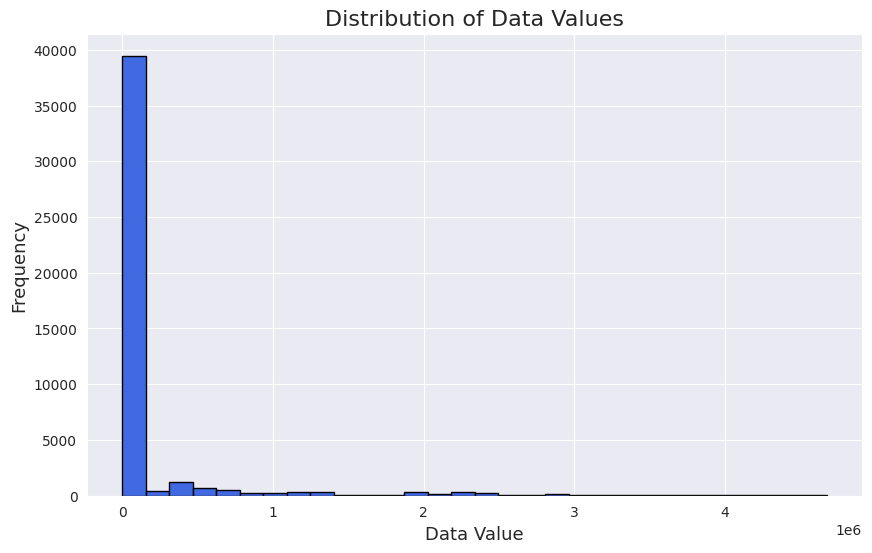

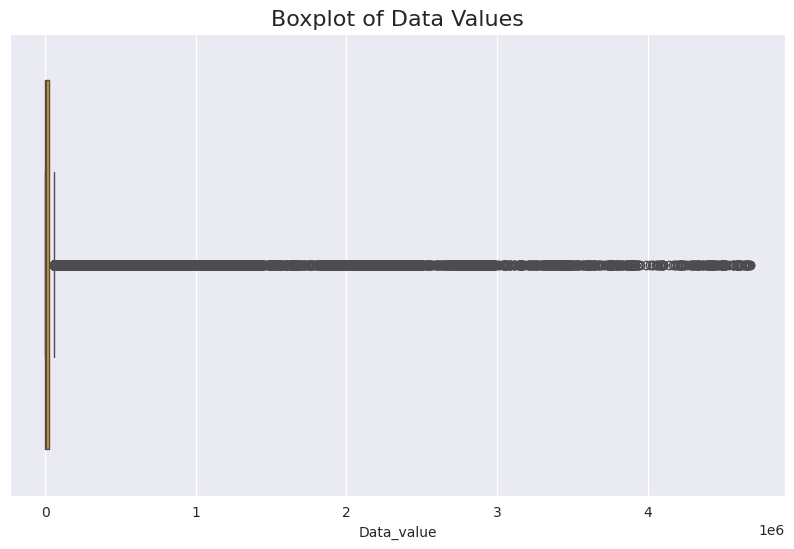

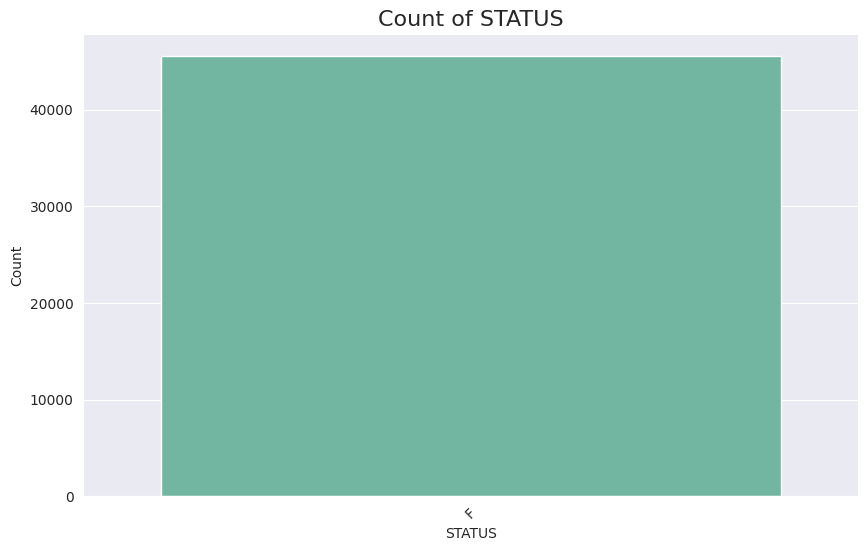

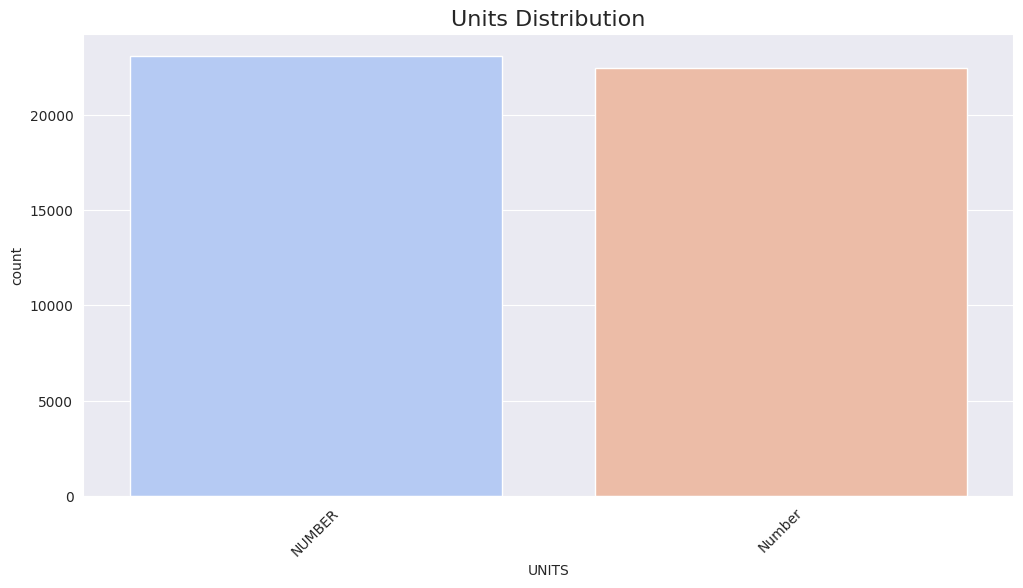

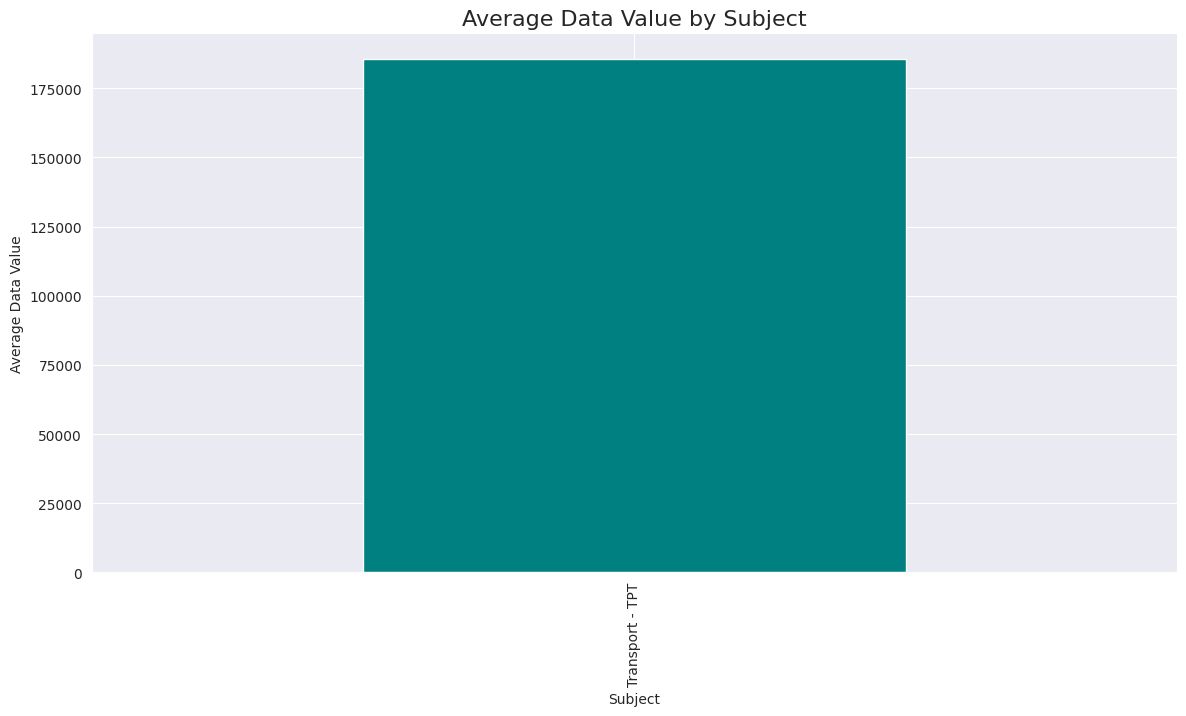

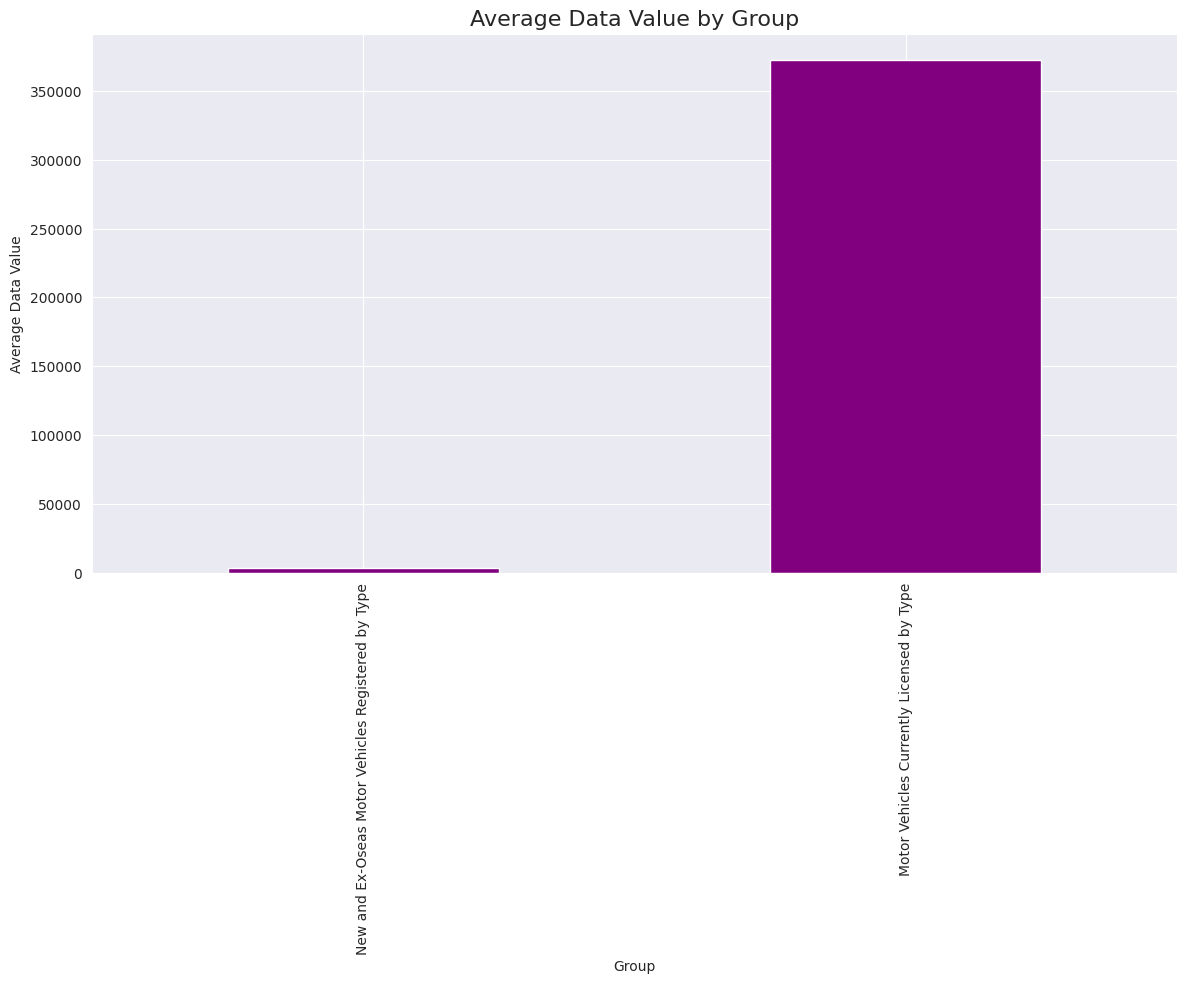

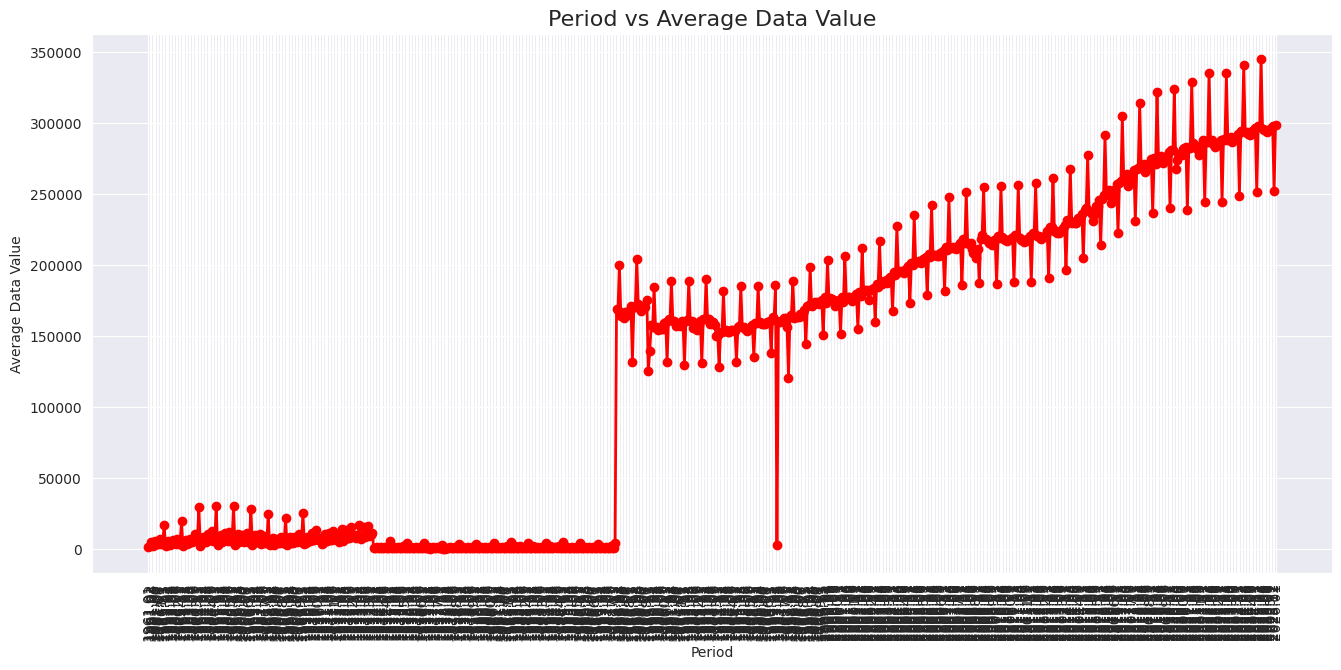

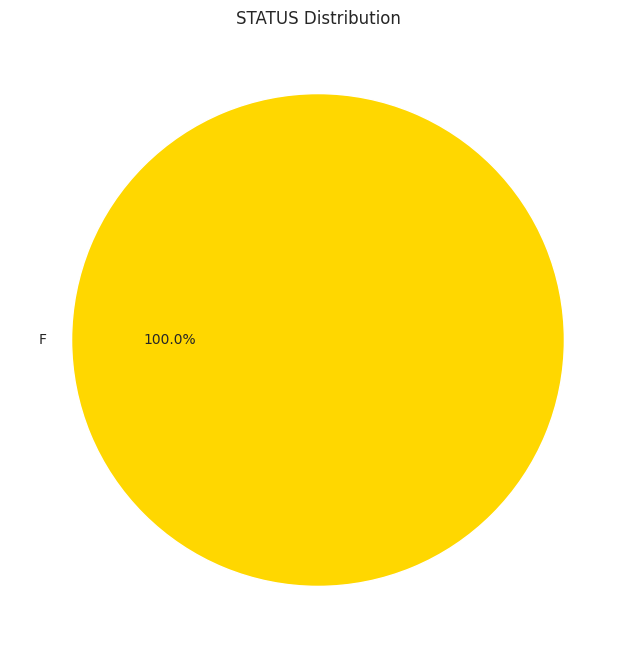

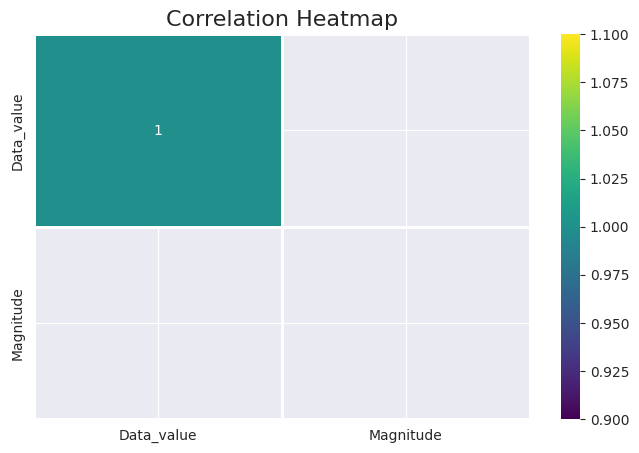

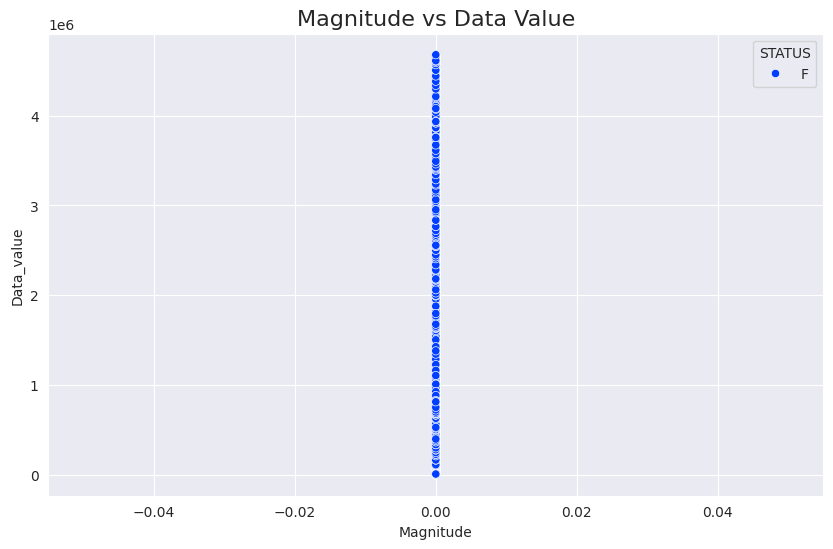

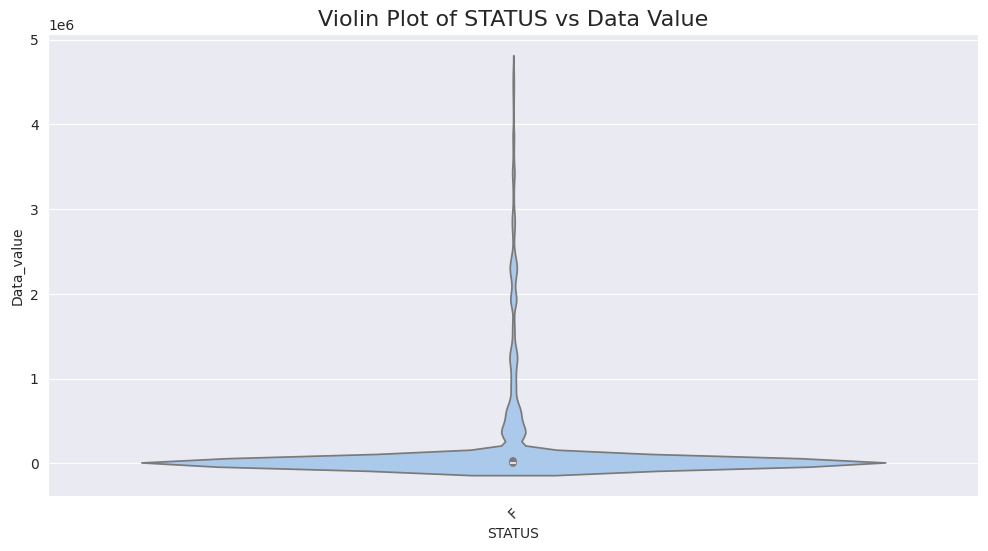

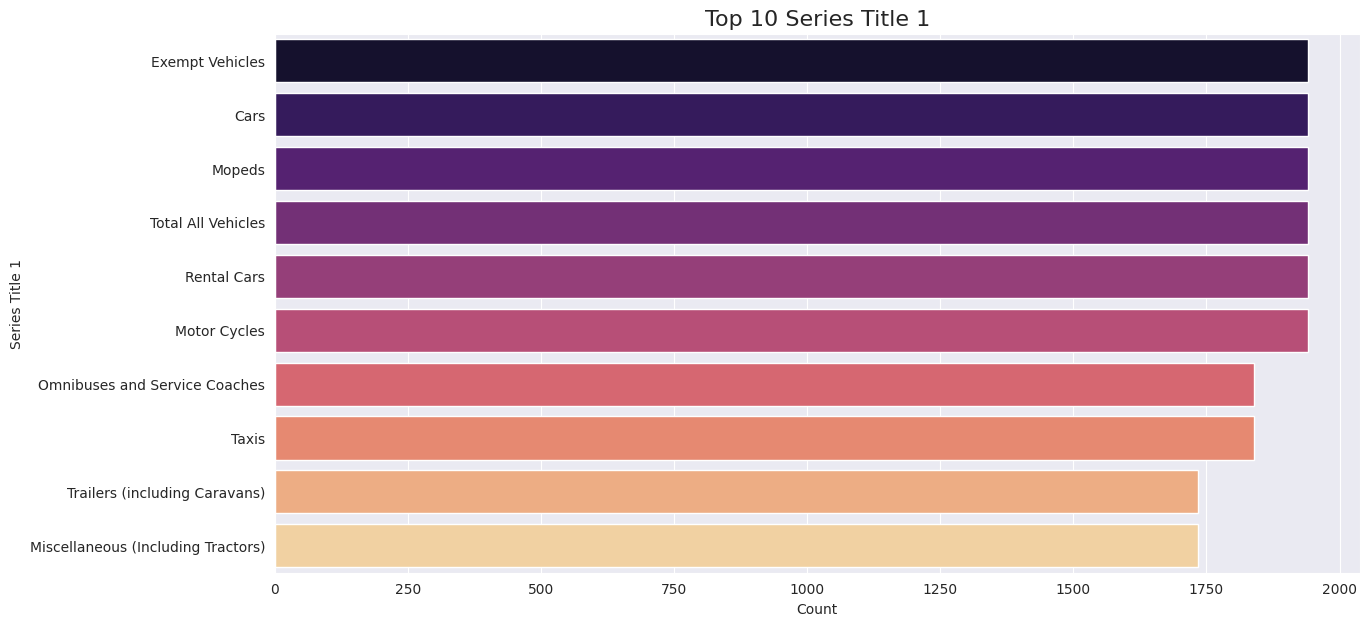

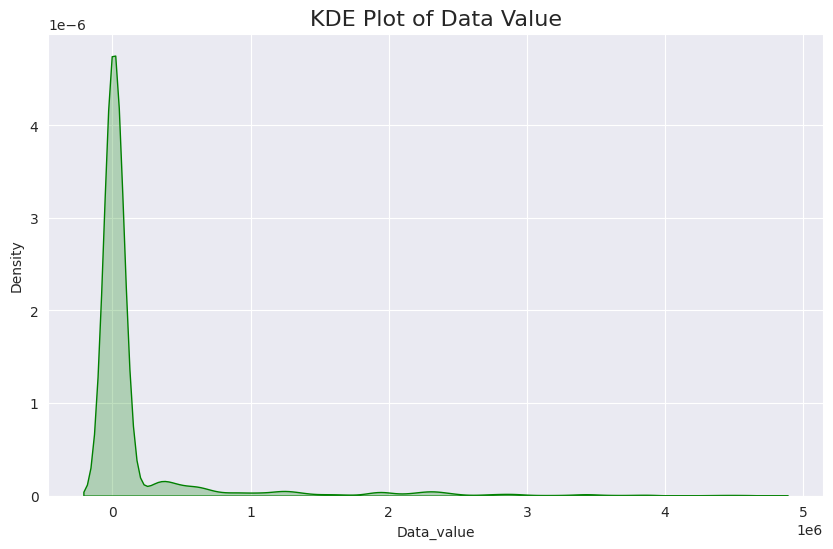

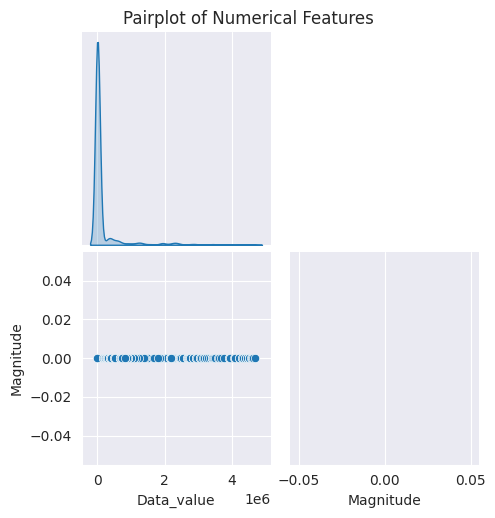

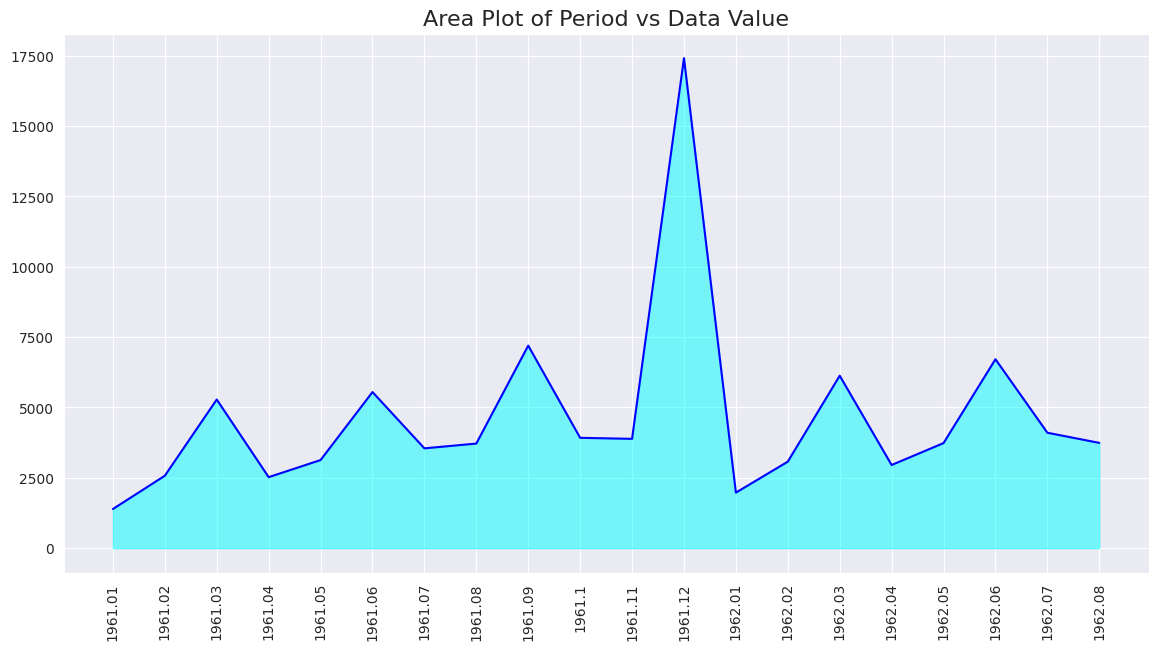


Visualization Completed Successfully!


In [13]:
# Convert Period to string for plotting
df['Period'] = df['Period'].astype(str)

# Convert Data_value to numeric
df['Data_value'] = pd.to_numeric(df['Data_value'], errors='coerce')

# Fill missing numeric values
df['Data_value'] = df['Data_value'].fillna(df['Data_value'].median())

# --------------------------------------------
# SET STYLE
# --------------------------------------------
sns.set_style("darkgrid")

# ============================================
# 1. HISTOGRAM OF DATA_VALUE
# ============================================
plt.figure(figsize=(10,6))

plt.hist(
    df['Data_value'],
    bins=30,
    color='royalblue',
    edgecolor='black'
)

plt.title("Distribution of Data Values", fontsize=16)
plt.xlabel("Data Value", fontsize=13)
plt.ylabel("Frequency", fontsize=13)

plt.show()

# ============================================
# 2. BOXPLOT OF DATA_VALUE
# ============================================
plt.figure(figsize=(10,6))

sns.boxplot(
    x=df['Data_value'],
    color='orange'
)

plt.title("Boxplot of Data Values", fontsize=16)

plt.show()

# ============================================
# 3. COUNTPLOT OF STATUS
# ============================================
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    x='STATUS',
    palette='Set2'
)

plt.title("Count of STATUS", fontsize=16)
plt.xlabel("STATUS")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

# ============================================
# 4. COUNTPLOT OF UNITS
# ============================================
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    x='UNITS',
    palette='coolwarm'
)

plt.title("Units Distribution", fontsize=16)

plt.xticks(rotation=45)

plt.show()

# ============================================
# 5. BARPLOT OF SUBJECT VS DATA_VALUE
# ============================================
plt.figure(figsize=(14,7))

subject_mean = df.groupby('Subject')['Data_value'].mean().sort_values()

subject_mean.plot(
    kind='bar',
    color='teal'
)

plt.title("Average Data Value by Subject", fontsize=16)
plt.xlabel("Subject")
plt.ylabel("Average Data Value")

plt.xticks(rotation=90)

plt.show()

# ============================================
# 6. GROUP WISE AVERAGE
# ============================================
plt.figure(figsize=(14,7))

group_mean = df.groupby('Group')['Data_value'].mean().sort_values()

group_mean.plot(
    kind='bar',
    color='purple'
)

plt.title("Average Data Value by Group", fontsize=16)
plt.xlabel("Group")
plt.ylabel("Average Data Value")

plt.xticks(rotation=90)

plt.show()

# ============================================
# 7. LINEPLOT OF PERIOD VS DATA_VALUE
# ============================================
plt.figure(figsize=(16,7))

period_mean = df.groupby('Period')['Data_value'].mean()

plt.plot(
    period_mean.index,
    period_mean.values,
    color='red',
    marker='o',
    linewidth=2
)

plt.title("Period vs Average Data Value", fontsize=16)
plt.xlabel("Period")
plt.ylabel("Average Data Value")

plt.xticks(rotation=90)

plt.show()

# ============================================
# 8. PIE CHART OF STATUS
# ============================================
status_counts = df['STATUS'].value_counts()

plt.figure(figsize=(8,8))

colors = ['gold', 'skyblue', 'lightgreen', 'salmon']

plt.pie(
    status_counts,
    labels=status_counts.index,
    autopct='%1.1f%%',
    colors=colors
)

plt.title("STATUS Distribution")

plt.show()

# ============================================
# 9. HEATMAP OF NUMERICAL FEATURES
# ============================================
plt.figure(figsize=(8,5))

numeric_df = df[['Data_value', 'Magnitude']]

corr = numeric_df.corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='viridis',
    linewidths=1
)

plt.title("Correlation Heatmap", fontsize=16)

plt.show()

# ============================================
# 10. SCATTERPLOT
# ============================================
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='Magnitude',
    y='Data_value',
    hue='STATUS',
    palette='bright'
)

plt.title("Magnitude vs Data Value", fontsize=16)

plt.show()

# ============================================
# 11. VIOLIN PLOT
# ============================================
plt.figure(figsize=(12,6))

sns.violinplot(
    data=df,
    x='STATUS',
    y='Data_value',
    palette='pastel'
)

plt.title("Violin Plot of STATUS vs Data Value", fontsize=16)

plt.xticks(rotation=45)

plt.show()

# ============================================
# 12. TOP SERIES TITLE ANALYSIS
# ============================================
plt.figure(figsize=(14,7))

top_titles = df['Series_title_1'].value_counts().head(10)

sns.barplot(
    x=top_titles.values,
    y=top_titles.index,
    palette='magma'
)

plt.title("Top 10 Series Title 1", fontsize=16)
plt.xlabel("Count")
plt.ylabel("Series Title 1")

plt.show()

# ============================================
# 13. KDE PLOT
# ============================================
plt.figure(figsize=(10,6))

sns.kdeplot(
    df['Data_value'],
    fill=True,
    color='green'
)

plt.title("KDE Plot of Data Value", fontsize=16)

plt.show()

# ============================================
# 14. PAIRPLOT
# ============================================
pair_df = df[['Data_value', 'Magnitude']]

sns.pairplot(
    pair_df,
    corner=True,
    diag_kind='kde'
)

plt.suptitle("Pairplot of Numerical Features", y=1.02)

plt.show()

# ============================================
# 15. AREA PLOT
# ============================================
period_area = df.groupby('Period')['Data_value'].mean().head(20)

plt.figure(figsize=(14,7))

plt.fill_between(
    range(len(period_area)),
    period_area.values,
    color='cyan',
    alpha=0.5
)

plt.plot(
    range(len(period_area)),
    period_area.values,
    color='blue'
)

plt.xticks(
    range(len(period_area)),
    period_area.index,
    rotation=90
)

plt.title("Area Plot of Period vs Data Value", fontsize=16)

plt.show()

# ============================================
# FINAL SUMMARY
# ============================================
print("\nVisualization Completed Successfully!")

## Feature engineering



TARGET CLASSES
['Motor Vehicles Currently Licensed by Type'
 'New and Ex-Oseas Motor Vehicles Registered by Type']


CATEGORICAL COLUMNS
['STATUS', 'UNITS', 'Subject', 'Series_title_1', 'Series_title_2']


NUMERICAL COLUMNS
['Period', 'Data_value', 'Suppressed', 'Magnitude', 'Series_title_3', 'Series_title_4', 'Series_title_5']


TRAIN TEST SPLIT
X_train Shape : (36433, 12)
X_test Shape  : (9109, 12)


MODEL : Logistic Regression
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
F1 Score  : 1.0000

Classification Report
------------------------------------------------------------
                                                    precision    recall  f1-score   support

         Motor Vehicles Currently Licensed by Type       1.00      1.00      1.00      4492
New and Ex-Oseas Motor Vehicles Registered by Type       1.00      1.00      1.00      4617

                                          accuracy                           1.00      9109
                                  

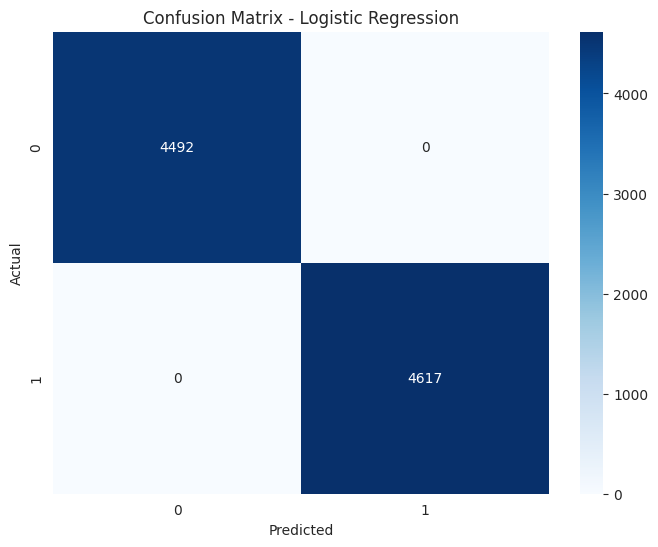

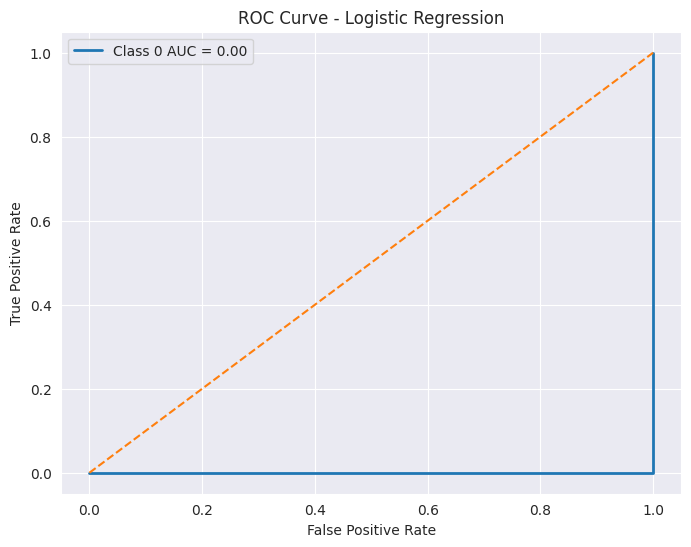



MODEL : Decision Tree
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
F1 Score  : 1.0000

Classification Report
------------------------------------------------------------
                                                    precision    recall  f1-score   support

         Motor Vehicles Currently Licensed by Type       1.00      1.00      1.00      4492
New and Ex-Oseas Motor Vehicles Registered by Type       1.00      1.00      1.00      4617

                                          accuracy                           1.00      9109
                                         macro avg       1.00      1.00      1.00      9109
                                      weighted avg       1.00      1.00      1.00      9109



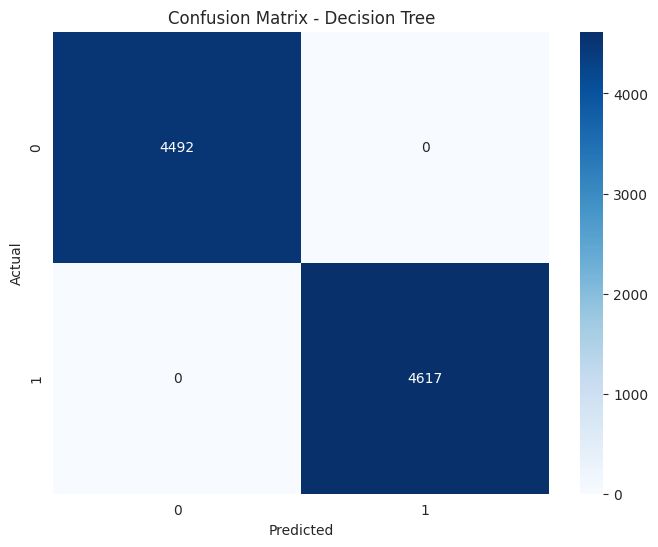

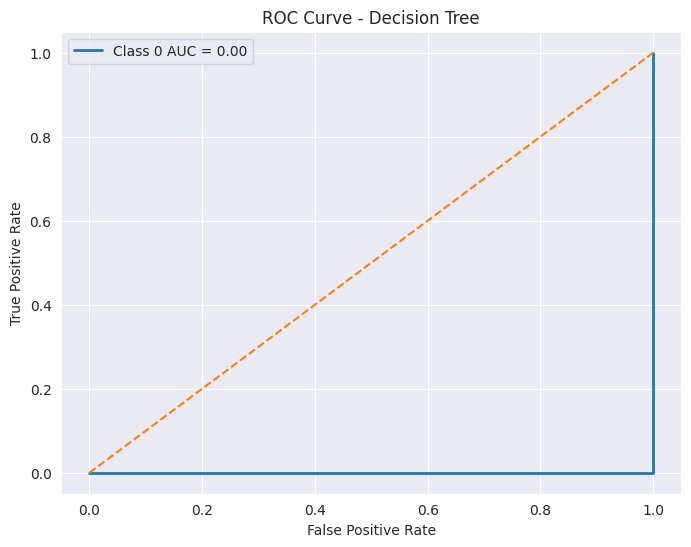



MODEL : Random Forest
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
F1 Score  : 1.0000

Classification Report
------------------------------------------------------------
                                                    precision    recall  f1-score   support

         Motor Vehicles Currently Licensed by Type       1.00      1.00      1.00      4492
New and Ex-Oseas Motor Vehicles Registered by Type       1.00      1.00      1.00      4617

                                          accuracy                           1.00      9109
                                         macro avg       1.00      1.00      1.00      9109
                                      weighted avg       1.00      1.00      1.00      9109



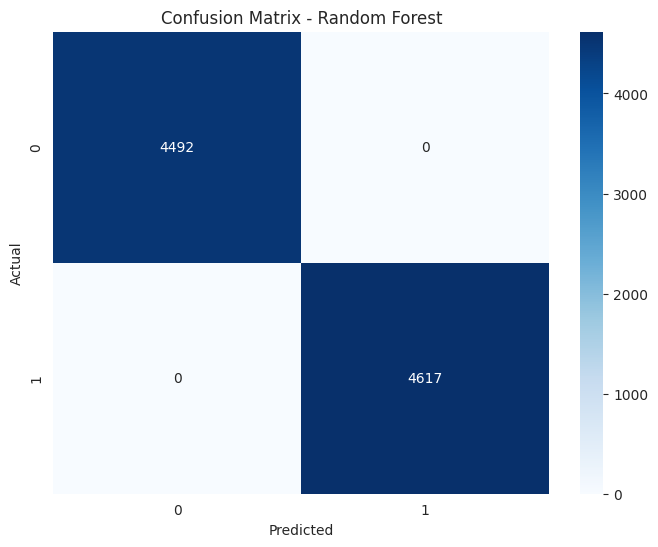

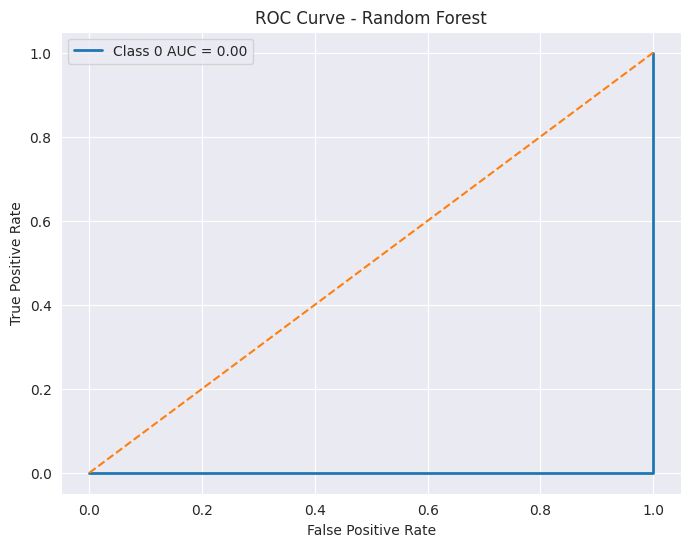



MODEL : Gradient Boosting
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
F1 Score  : 1.0000

Classification Report
------------------------------------------------------------
                                                    precision    recall  f1-score   support

         Motor Vehicles Currently Licensed by Type       1.00      1.00      1.00      4492
New and Ex-Oseas Motor Vehicles Registered by Type       1.00      1.00      1.00      4617

                                          accuracy                           1.00      9109
                                         macro avg       1.00      1.00      1.00      9109
                                      weighted avg       1.00      1.00      1.00      9109



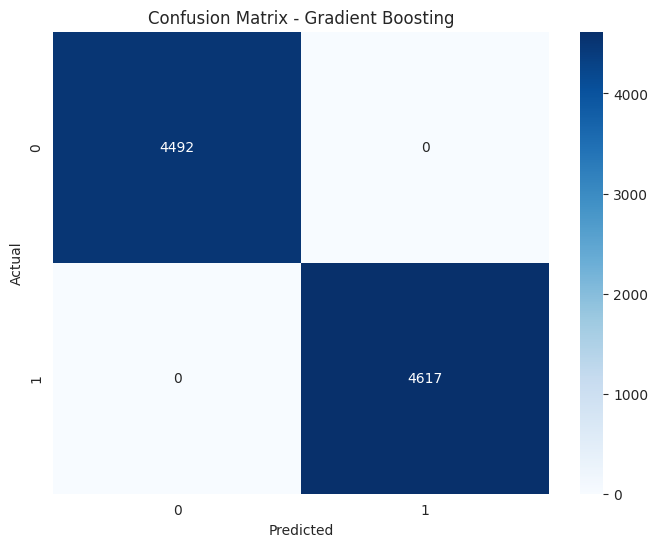

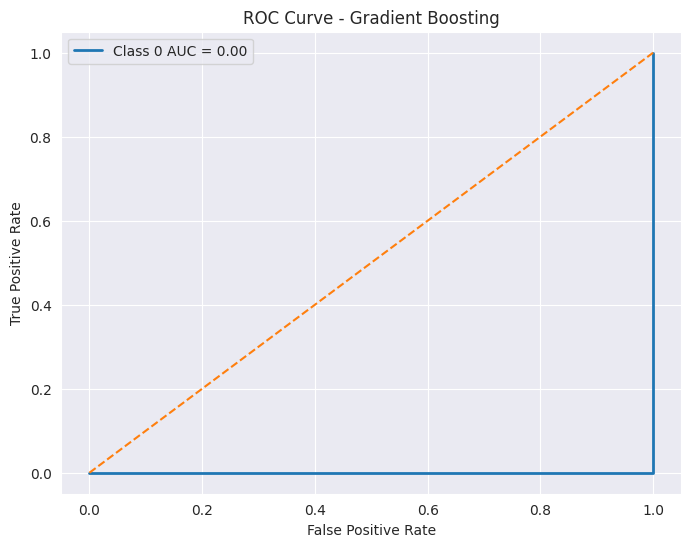



MODEL : KNN
Accuracy  : 0.8610
Precision : 0.8642
Recall    : 0.8610
F1 Score  : 0.8608

Classification Report
------------------------------------------------------------
                                                    precision    recall  f1-score   support

         Motor Vehicles Currently Licensed by Type       0.83      0.91      0.87      4492
New and Ex-Oseas Motor Vehicles Registered by Type       0.90      0.82      0.86      4617

                                          accuracy                           0.86      9109
                                         macro avg       0.86      0.86      0.86      9109
                                      weighted avg       0.86      0.86      0.86      9109



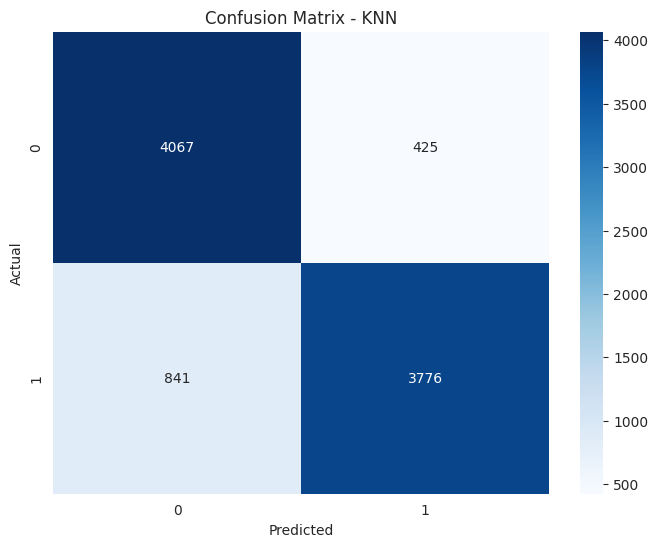

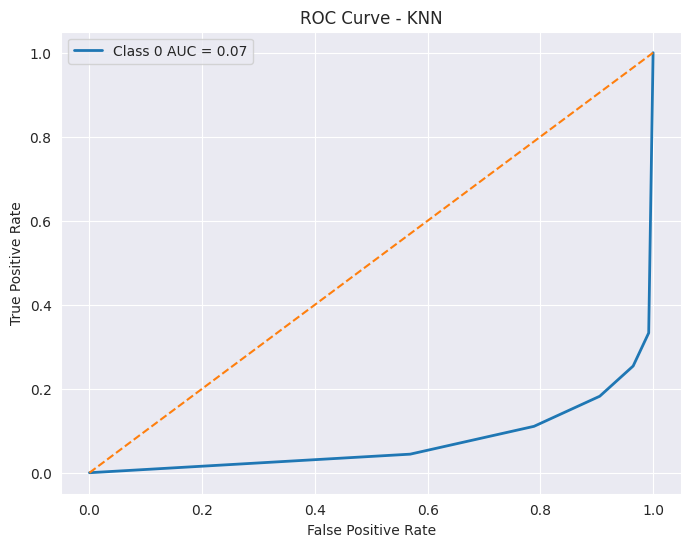



FINAL MODEL COMPARISON
                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  1.000000   1.000000  1.000000  1.000000
1        Decision Tree  1.000000   1.000000  1.000000  1.000000
2        Random Forest  1.000000   1.000000  1.000000  1.000000
3    Gradient Boosting  1.000000   1.000000  1.000000  1.000000
4                  KNN  0.861017   0.864222  0.861017  0.860814


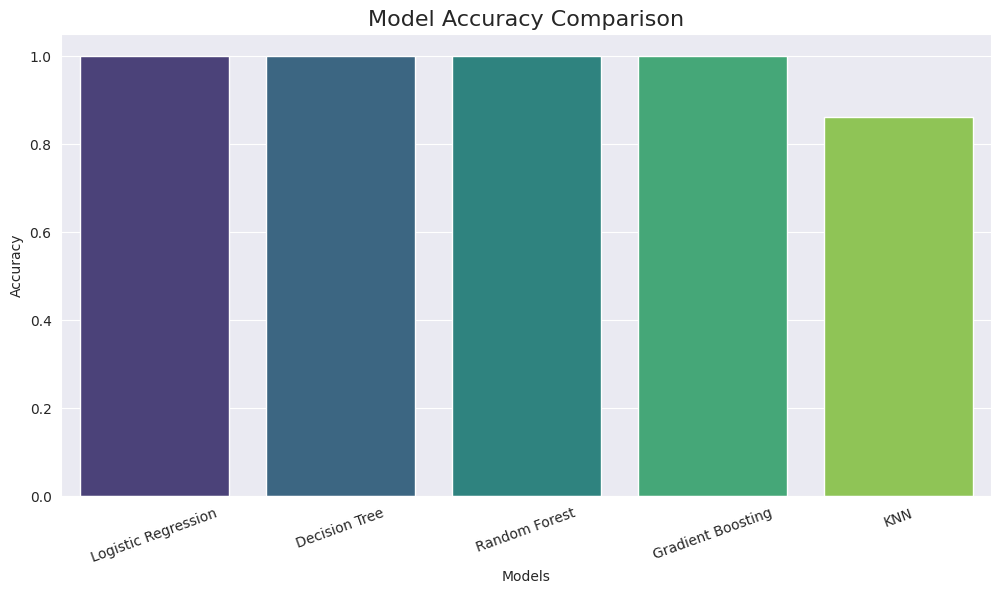

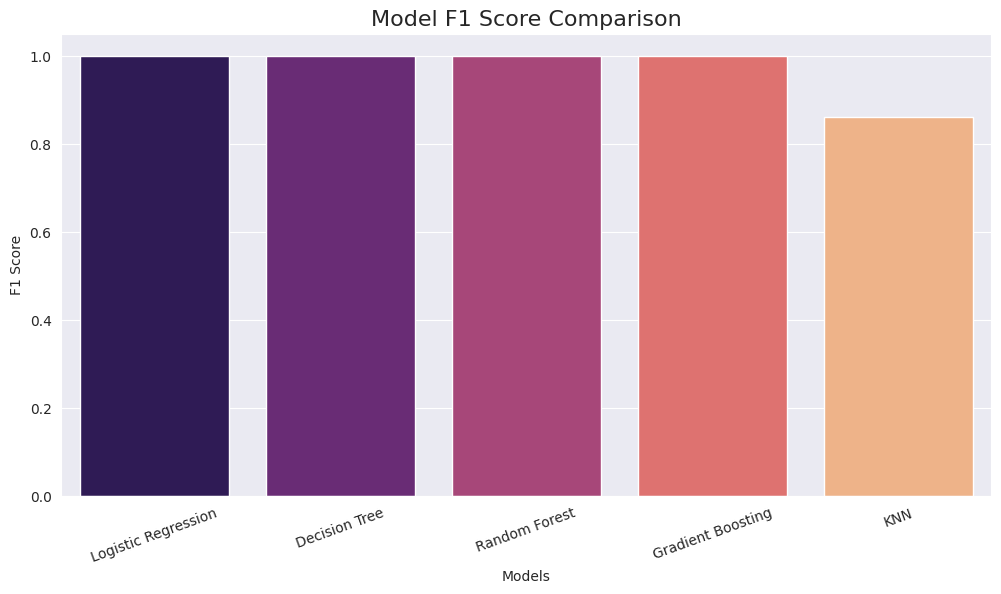



BEST MODEL
Best Model     : Logistic Regression
Best Accuracy  : 1.0000
Best F1 Score  : 1.0000


MACHINE LEARNING PIPELINE COMPLETED SUCCESSFULLY


In [14]:
# ============================================================
# COMPLETE MACHINE LEARNING PIPELINE
# ============================================================
# TARGET COLUMN:
# Group
#
# FEATURES:


import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Machine Learning Algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# ROC Curve
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc


for col in df.columns:

    try:
        df[col] = pd.to_numeric(df[col])

    except:
        pass

# ============================================================
# TARGET COLUMN
# ============================================================

target_column = 'Group'

# ============================================================
# REMOVE ROWS WITH MISSING TARGET
# ============================================================

df = df.dropna(subset=[target_column])

# ============================================================
# REMOVE HIGH CARDINALITY COLUMN
# ============================================================

drop_columns = ['Series_reference']

existing_drop_cols = [col for col in drop_columns if col in df.columns]

# ============================================================
# FEATURES AND TARGET
# ============================================================

X = df.drop(columns=[target_column] + existing_drop_cols)

y = df[target_column]

# ============================================================
# LABEL ENCODING TARGET
# ============================================================

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("\n")

print("="*60)
print("TARGET CLASSES")
print("="*60)

print(label_encoder.classes_)

# ============================================================
# IDENTIFY CATEGORICAL AND NUMERICAL COLUMNS
# ============================================================

categorical_columns = X.select_dtypes(
    include=['object']
).columns.tolist()

numerical_columns = X.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

print("\n")

print("="*60)
print("CATEGORICAL COLUMNS")
print("="*60)

print(categorical_columns)

print("\n")

print("="*60)
print("NUMERICAL COLUMNS")
print("="*60)

print(numerical_columns)

# ============================================================
# TRAIN TEST SPLIT
# ============================================================
# IMPORTANT:
# Splitting BEFORE preprocessing prevents data leakage
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("\n")

print("="*60)
print("TRAIN TEST SPLIT")
print("="*60)

print("X_train Shape :", X_train.shape)
print("X_test Shape  :", X_test.shape)

# ============================================================
# PREPROCESSING PIPELINE
# ============================================================

# Numerical preprocessing
numeric_transformer = Pipeline(steps=[

    ('imputer', SimpleImputer(strategy='median'))

])

# Categorical preprocessing
categorical_transformer = Pipeline(steps=[

    ('imputer', SimpleImputer(strategy='most_frequent')),

    ('encoder', OneHotEncoder(handle_unknown='ignore'))

])

# Combine preprocessing
preprocessor = ColumnTransformer(

    transformers=[

        ('num', numeric_transformer, numerical_columns),

        ('cat', categorical_transformer, categorical_columns)

    ]

)

# ============================================================
# MACHINE LEARNING MODELS
# ============================================================

models = {

    "Logistic Regression": LogisticRegression(
        max_iter=1000
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=5
    )

}

# ============================================================
# STORE RESULTS
# ============================================================

results = []

# ============================================================
# MODEL TRAINING LOOP
# ============================================================

for model_name, model in models.items():

    print("\n")
    print("="*80)
    print(f"MODEL : {model_name}")
    print("="*80)

    # ========================================================
    # CREATE PIPELINE
    # ========================================================

    pipeline = Pipeline(steps=[

        ('preprocessor', preprocessor),

        ('model', model)

    ])

    # ========================================================
    # TRAIN MODEL
    # ========================================================

    pipeline.fit(X_train, y_train)

    # ========================================================
    # PREDICTIONS
    # ========================================================

    y_pred = pipeline.predict(X_test)

    # ========================================================
    # METRICS
    # ========================================================

    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(
        y_test,
        y_pred,
        average='weighted'
    )

    recall = recall_score(
        y_test,
        y_pred,
        average='weighted'
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average='weighted'
    )

    # ========================================================
    # PRINT METRICS
    # ========================================================

    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 Score  : {f1:.4f}")

    # ========================================================
    # CLASSIFICATION REPORT
    # ========================================================

    print("\nClassification Report")
    print("-"*60)

    print(

        classification_report(
            y_test,
            y_pred,
            target_names=label_encoder.classes_
        )

    )

    # ========================================================
    # CONFUSION MATRIX
    # ========================================================

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(8,6))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues'
    )

    plt.title(f'Confusion Matrix - {model_name}')

    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

    # ========================================================
    # ROC CURVE
    # ========================================================

    try:

        # Predict probabilities
        y_prob = pipeline.predict_proba(X_test)

        # Binarize output
        y_test_bin = label_binarize(
            y_test,
            classes=np.unique(y_test)
        )

        n_classes = y_test_bin.shape[1]

        plt.figure(figsize=(8,6))

        # ROC for each class
        for i in range(n_classes):

            fpr, tpr, _ = roc_curve(
                y_test_bin[:, i],
                y_prob[:, i]
            )

            roc_auc = auc(fpr, tpr)

            plt.plot(
                fpr,
                tpr,
                linewidth=2,
                label=f'Class {i} AUC = {roc_auc:.2f}'
            )

        plt.plot([0,1], [0,1], linestyle='--')

        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")

        plt.title(f"ROC Curve - {model_name}")

        plt.legend()

        plt.show()

    except:

        print("\nROC Curve not supported for this model.")

    # ========================================================
    # SAVE RESULTS
    # ========================================================

    results.append({

        'Model': model_name,

        'Accuracy': accuracy,

        'Precision': precision,

        'Recall': recall,

        'F1 Score': f1

    })

# ============================================================
# RESULTS DATAFRAME
# ============================================================

results_df = pd.DataFrame(results)

# ============================================================
# SORT RESULTS
# ============================================================

results_df = results_df.sort_values(
    by='Accuracy',
    ascending=False
)

# ============================================================
# FINAL RESULTS
# ============================================================

print("\n")

print("="*80)
print("FINAL MODEL COMPARISON")
print("="*80)

print(results_df)

# ============================================================
# ACCURACY VISUALIZATION
# ============================================================

plt.figure(figsize=(12,6))

sns.barplot(
    data=results_df,
    x='Model',
    y='Accuracy',
    palette='viridis'
)

plt.title("Model Accuracy Comparison", fontsize=16)

plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.xticks(rotation=20)

plt.show()

# ============================================================
# F1 SCORE VISUALIZATION
# ============================================================

plt.figure(figsize=(12,6))

sns.barplot(
    data=results_df,
    x='Model',
    y='F1 Score',
    palette='magma'
)

plt.title("Model F1 Score Comparison", fontsize=16)

plt.xlabel("Models")
plt.ylabel("F1 Score")

plt.xticks(rotation=20)

plt.show()

# ============================================================
# BEST MODEL
# ============================================================

best_model = results_df.iloc[0]

print("\n")

print("="*80)
print("BEST MODEL")
print("="*80)

print(f"Best Model     : {best_model['Model']}")
print(f"Best Accuracy  : {best_model['Accuracy']:.4f}")
print(f"Best F1 Score  : {best_model['F1 Score']:.4f}")

# ============================================================
# COMPLETE
# ============================================================

print("\n")
print("="*80)
print("MACHINE LEARNING PIPELINE COMPLETED SUCCESSFULLY")
print("="*80)